In [6]:
import numpy as np
import pandas as pd
import scanpy as sc
import decoupler as dc
import anndata
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [7]:
sns.set_context("paper", font_scale=2) # set some nice global plotting settings.


(32, 50467)


/opt/apps/python/3.10.2/lib/python3.10/site-packages/scanpy/preprocessing/_pca/__init__.py:227: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(adata, mask_var, use_highly_variable)


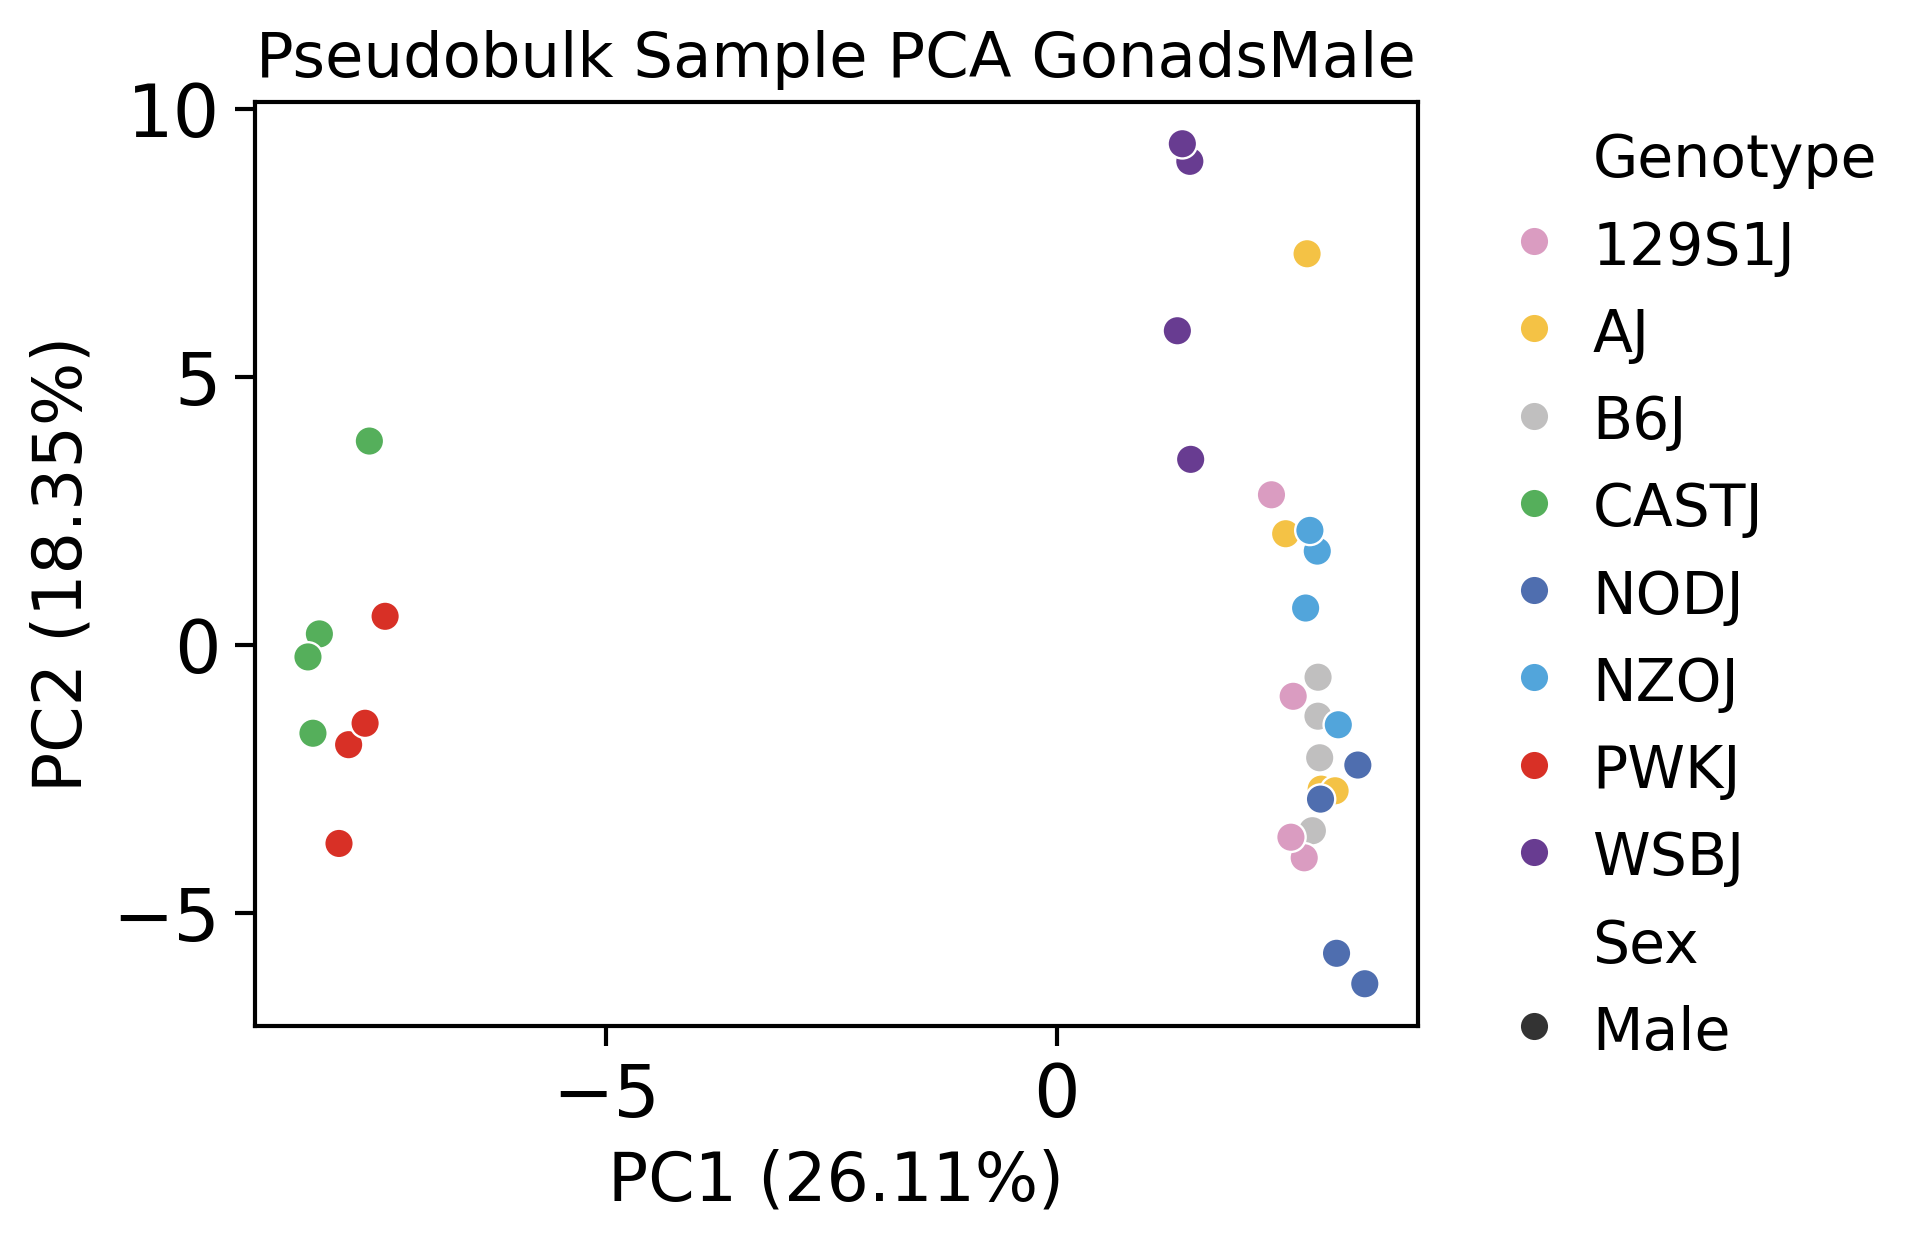

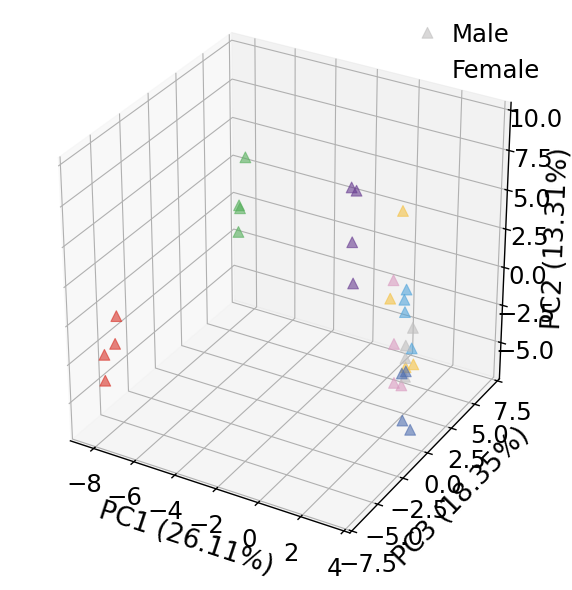

(32, 46590)


/opt/apps/python/3.10.2/lib/python3.10/site-packages/scanpy/preprocessing/_pca/__init__.py:227: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(adata, mask_var, use_highly_variable)


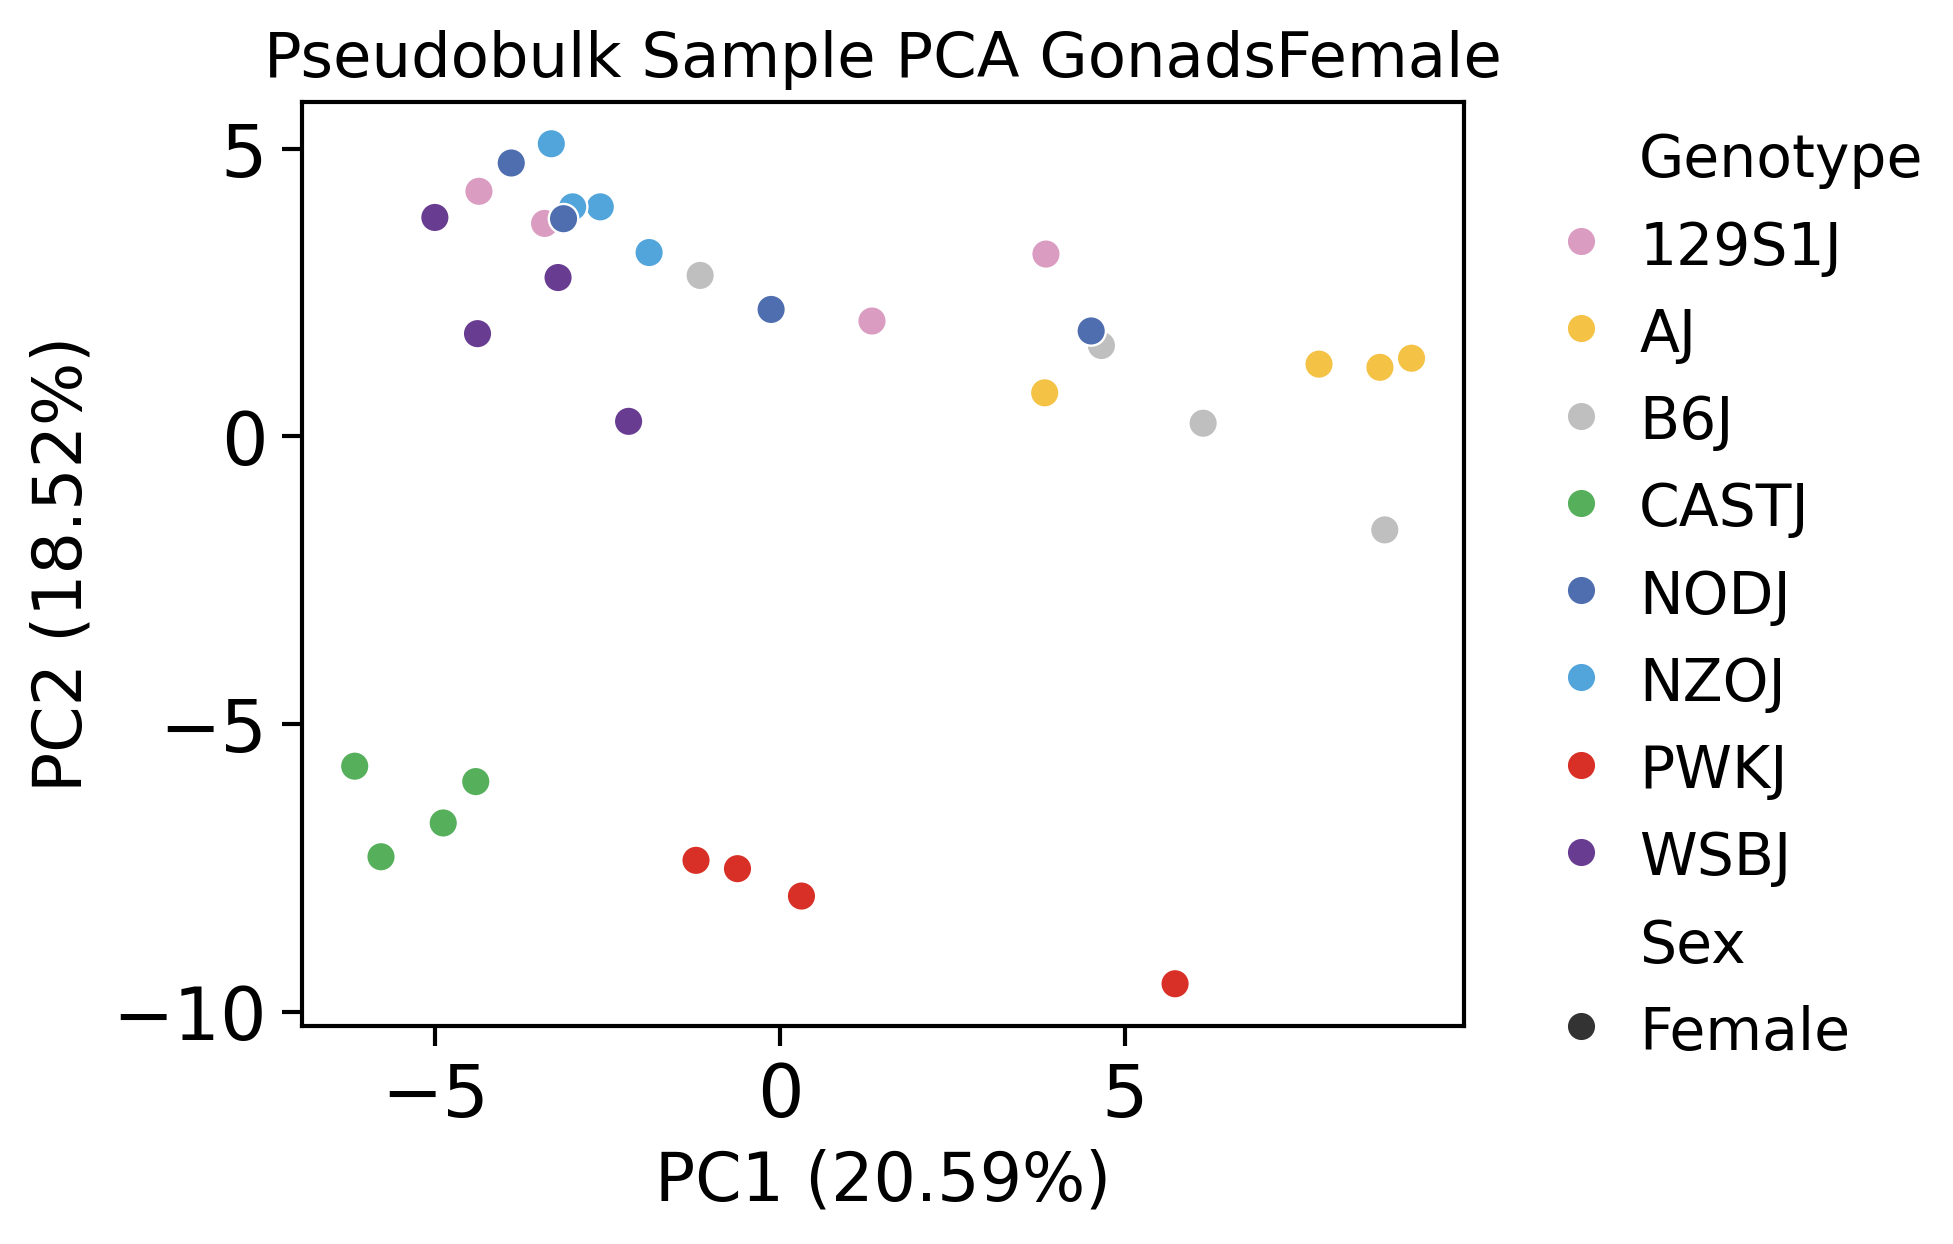

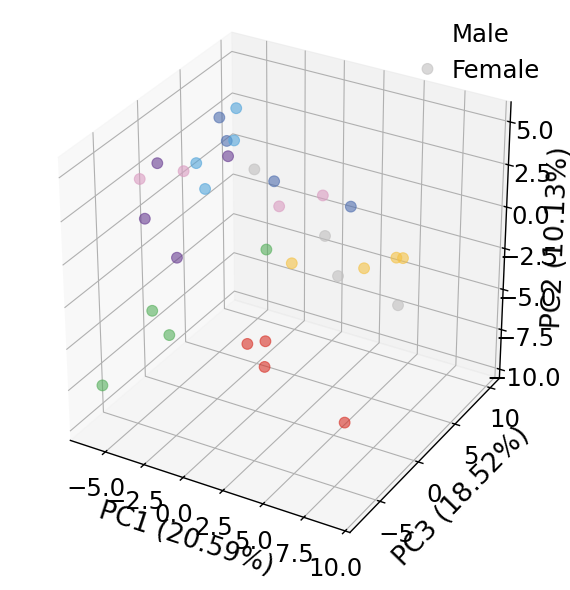

(66, 45546)


/opt/apps/python/3.10.2/lib/python3.10/site-packages/scanpy/preprocessing/_pca/__init__.py:227: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(adata, mask_var, use_highly_variable)


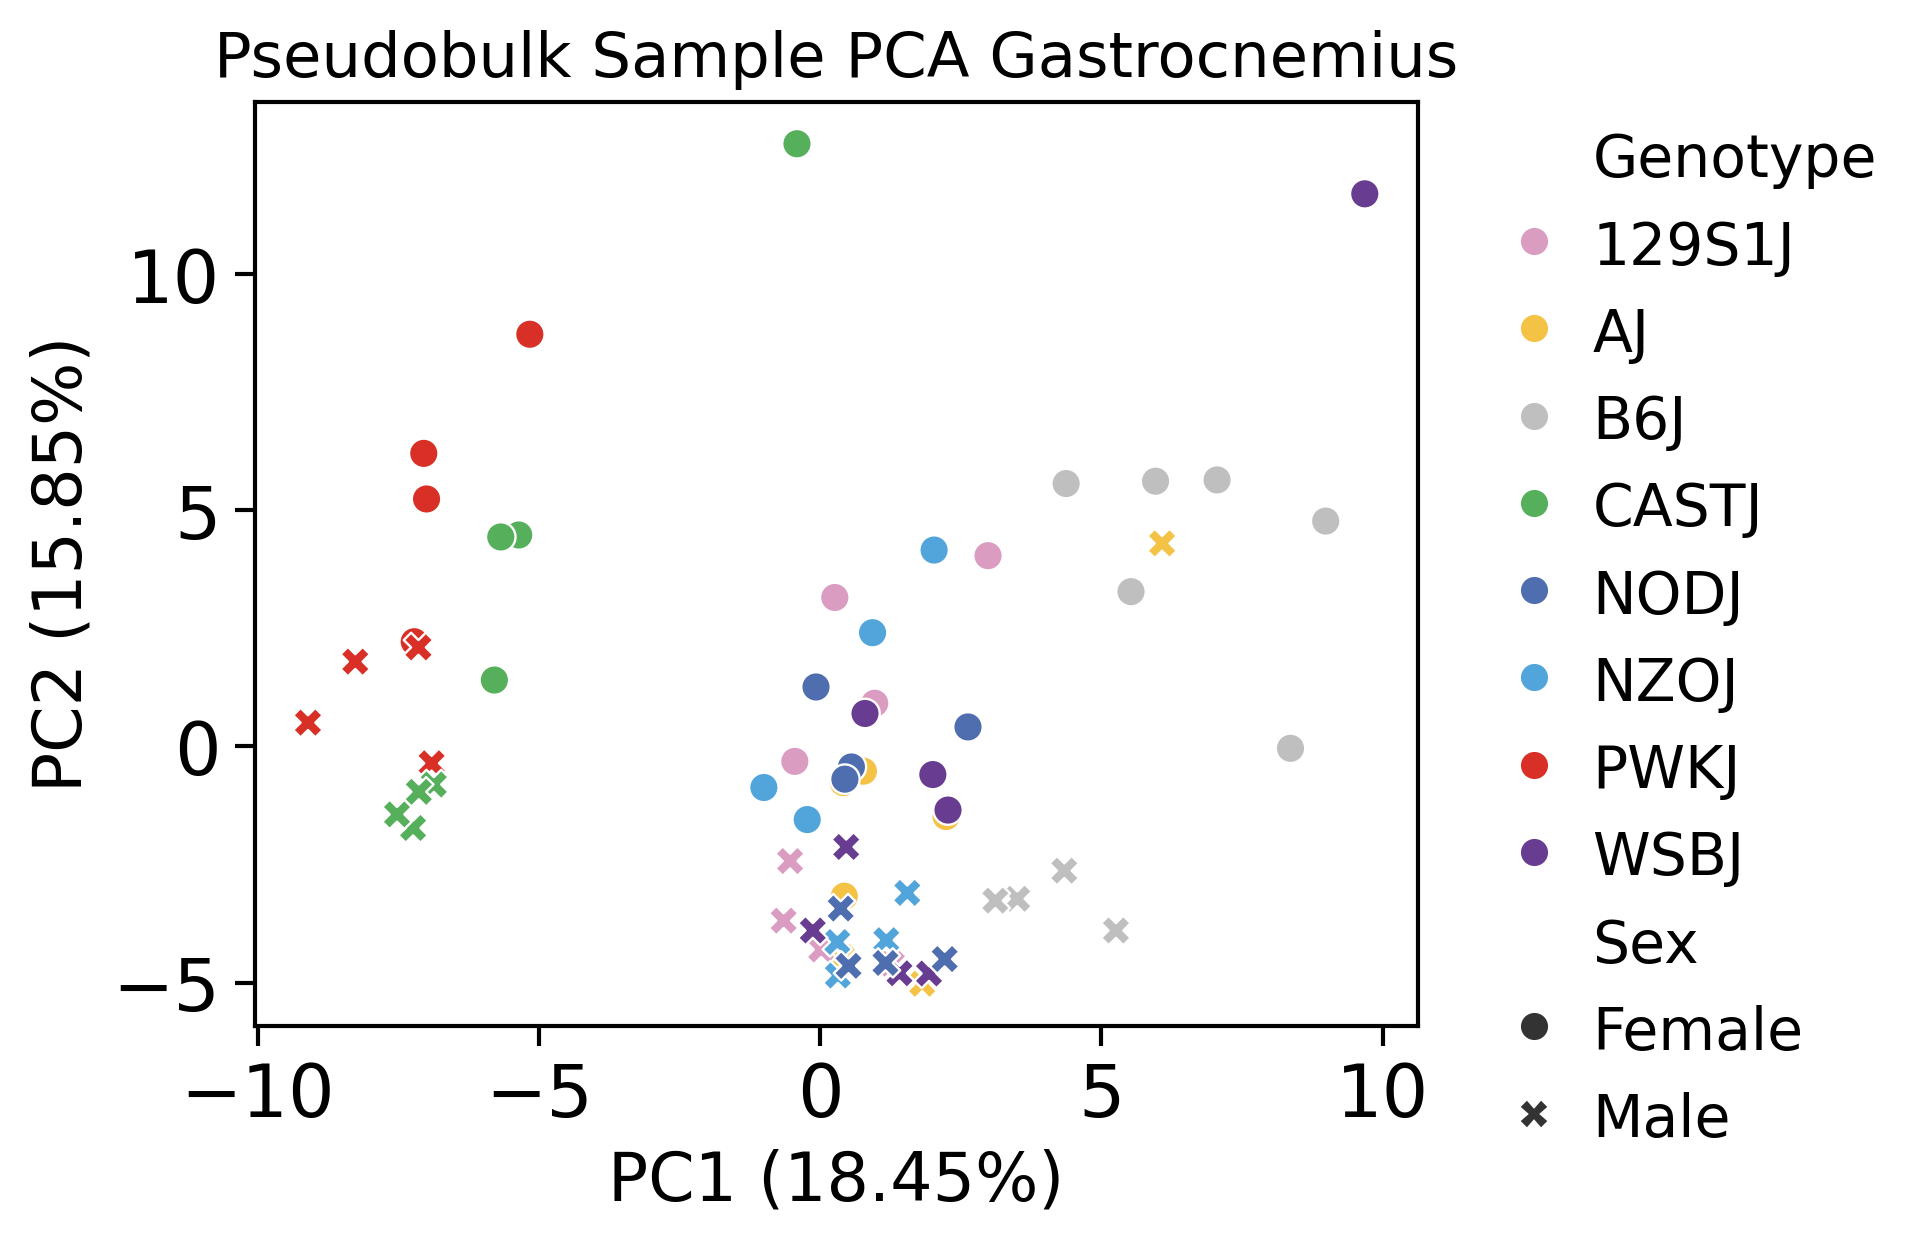

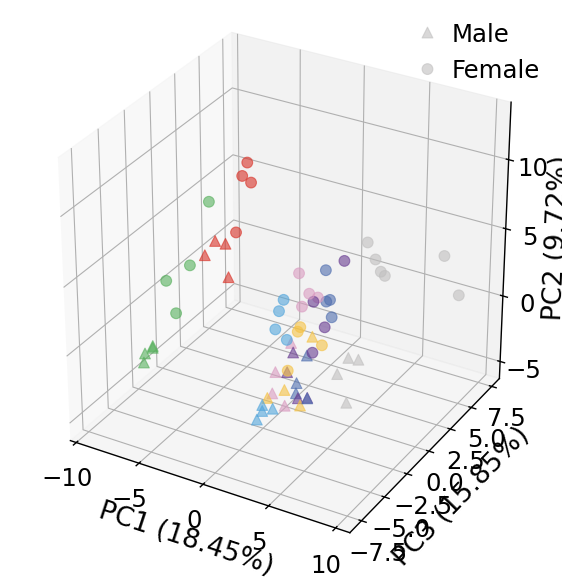

(63, 44565)


/opt/apps/python/3.10.2/lib/python3.10/site-packages/scanpy/preprocessing/_pca/__init__.py:227: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(adata, mask_var, use_highly_variable)


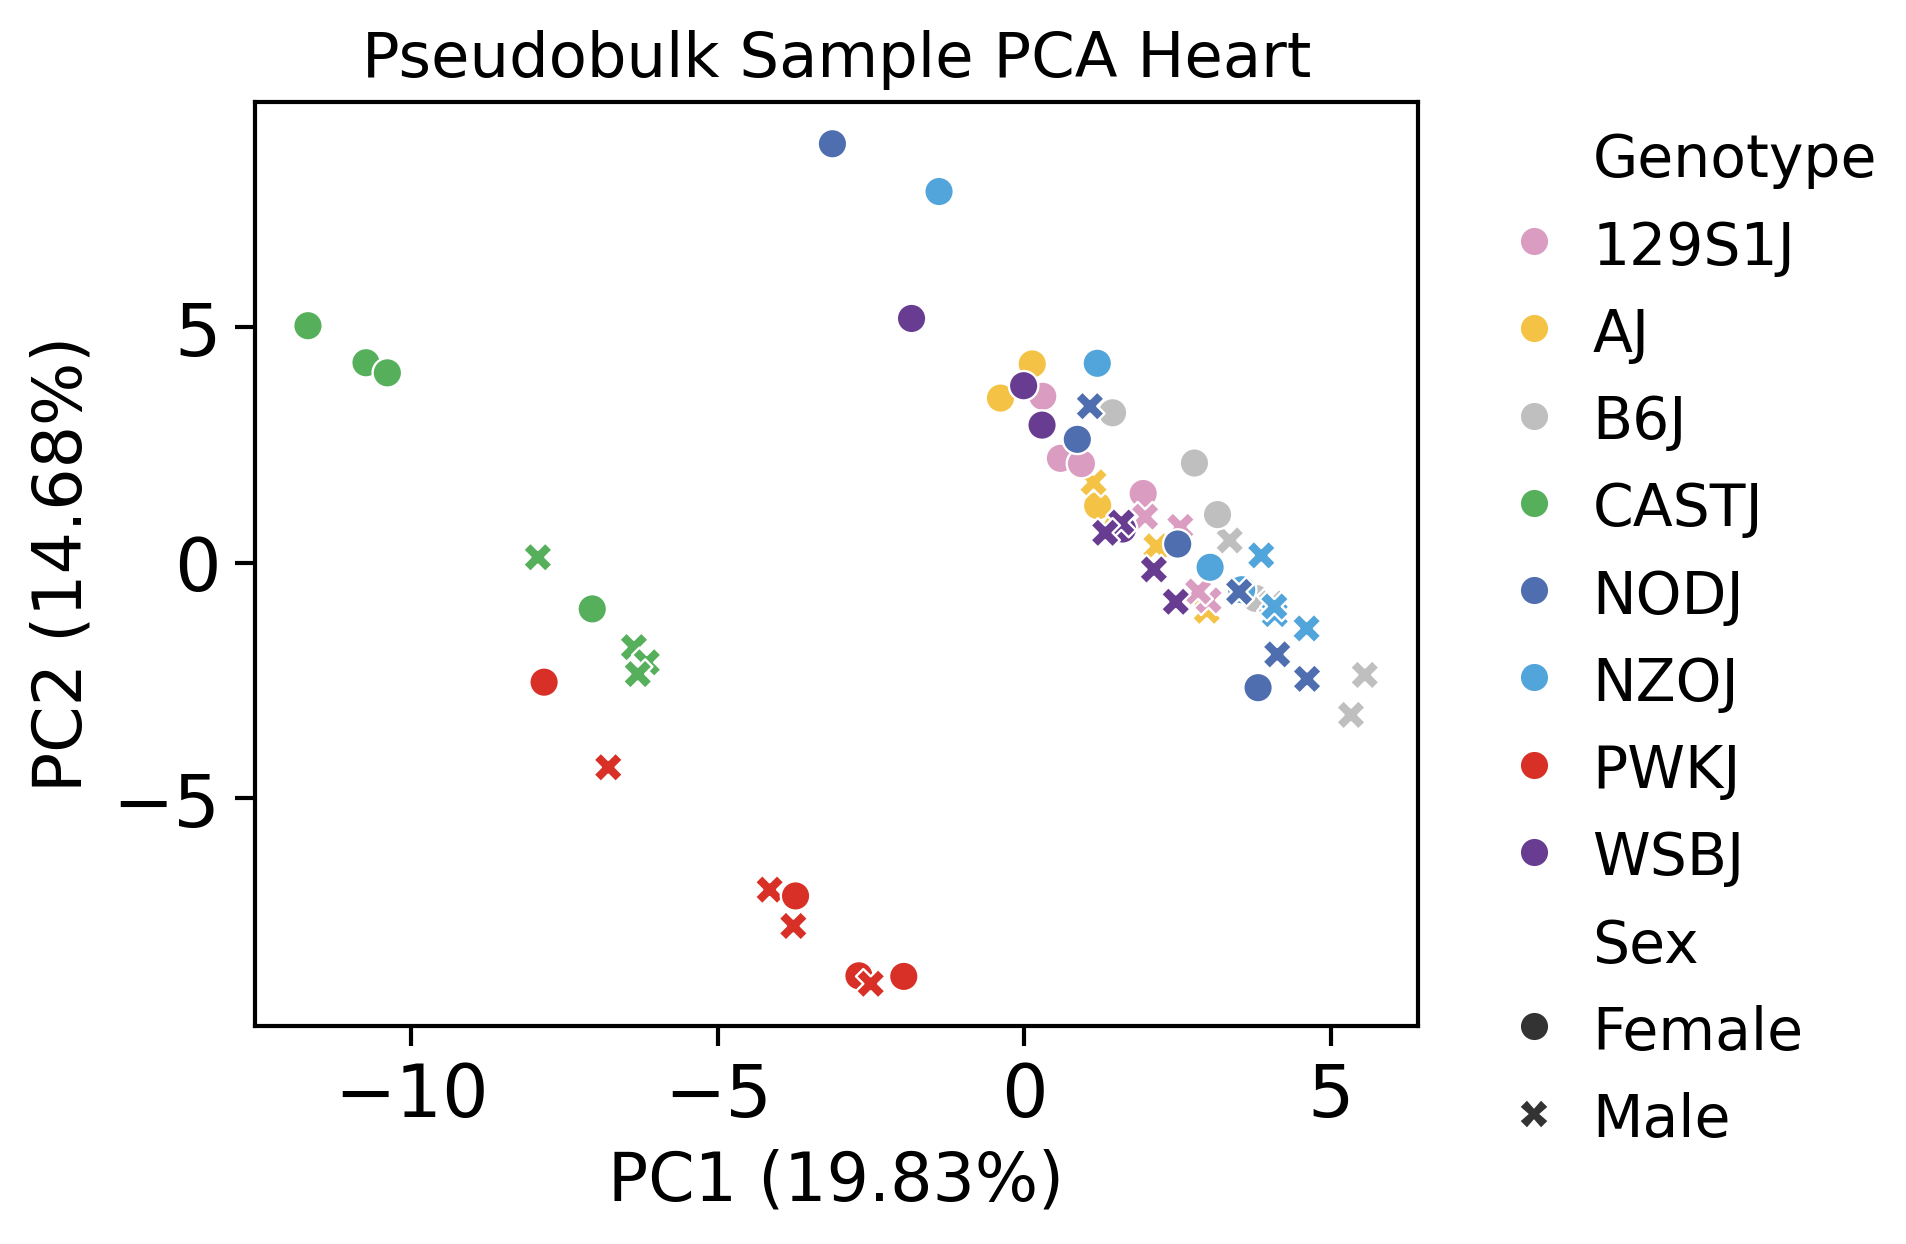

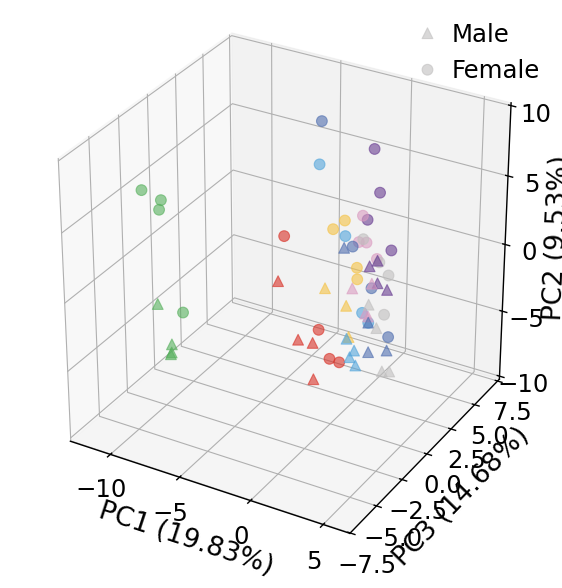

(64, 47969)


/opt/apps/python/3.10.2/lib/python3.10/site-packages/scanpy/preprocessing/_pca/__init__.py:227: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(adata, mask_var, use_highly_variable)


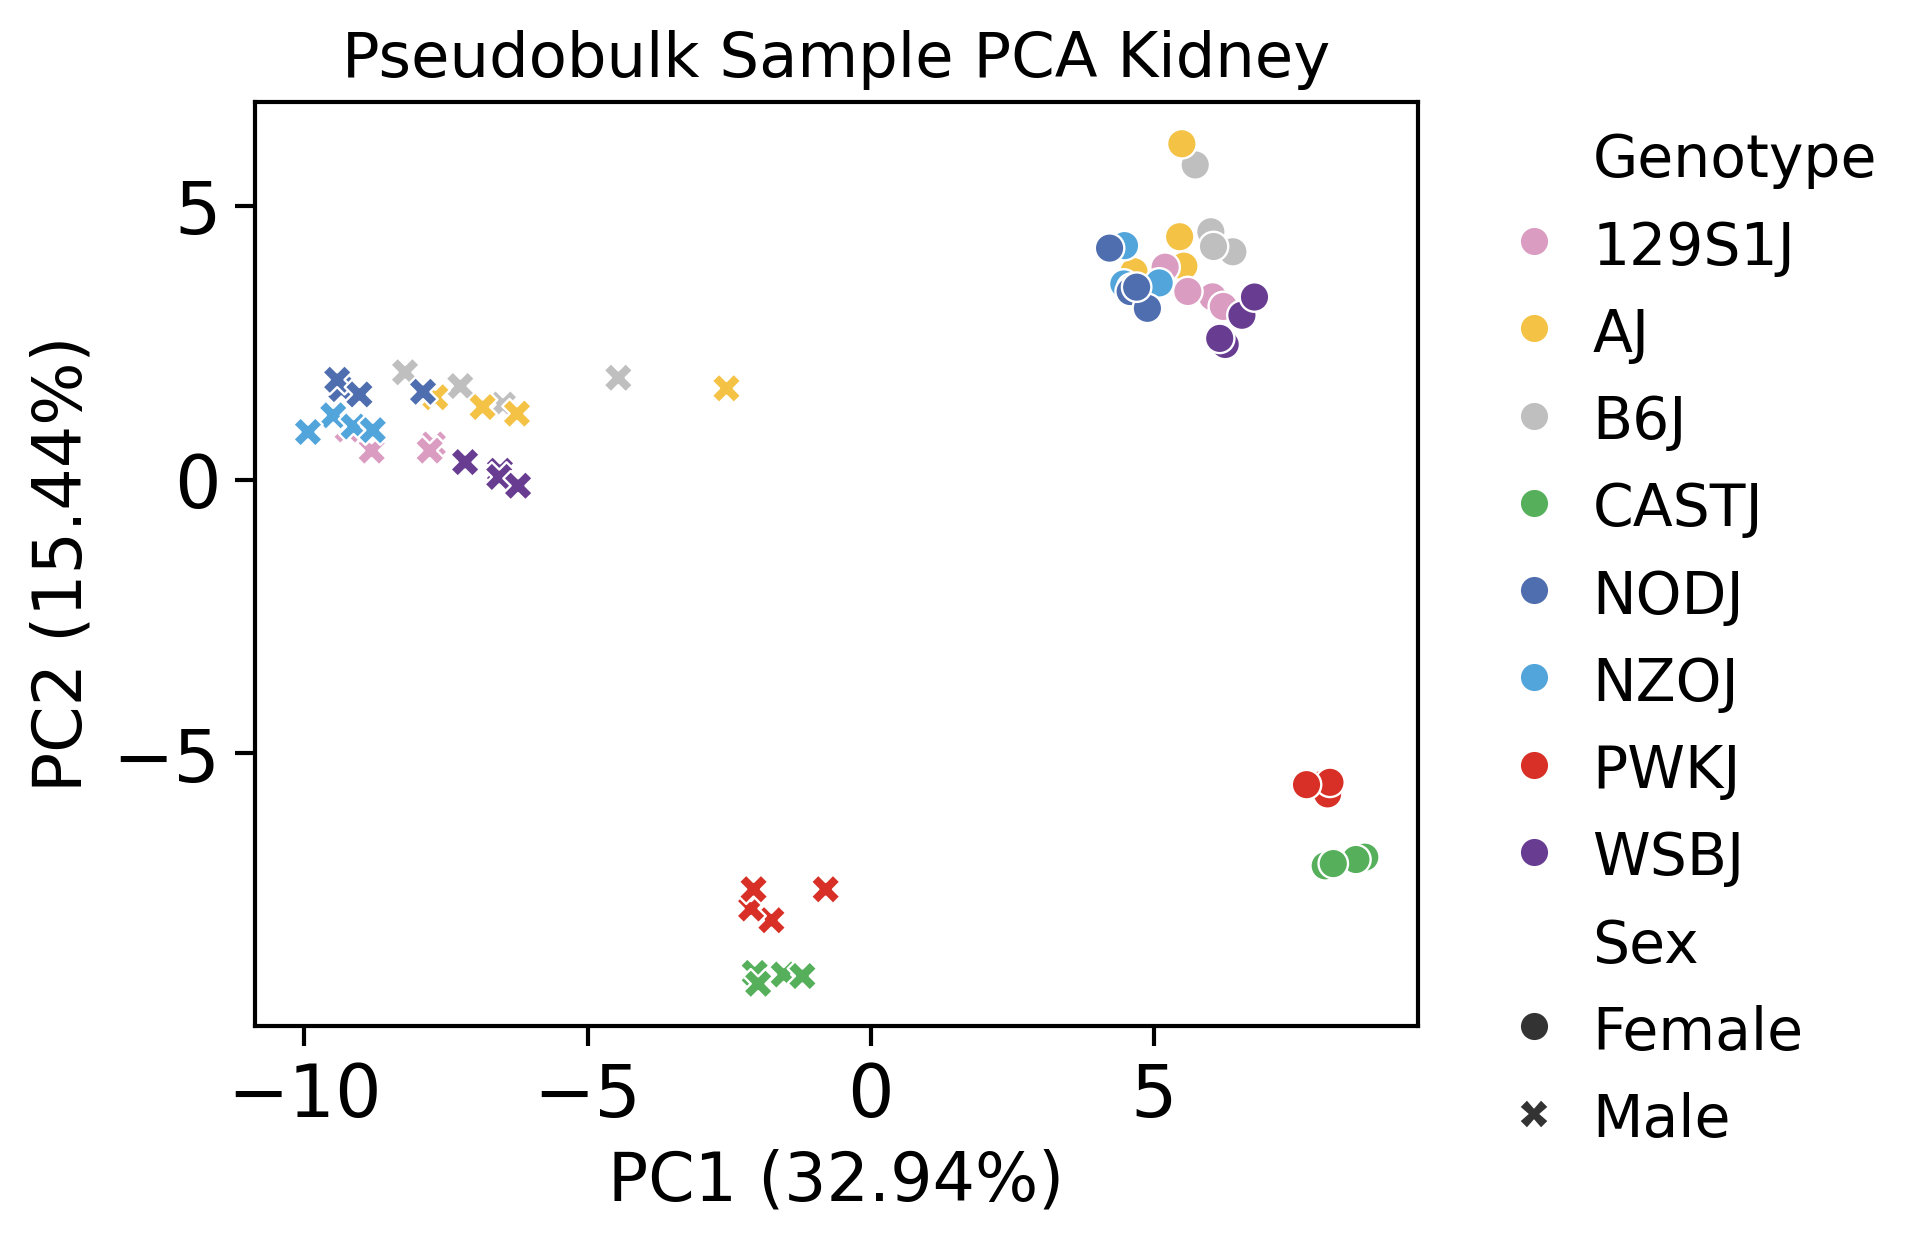

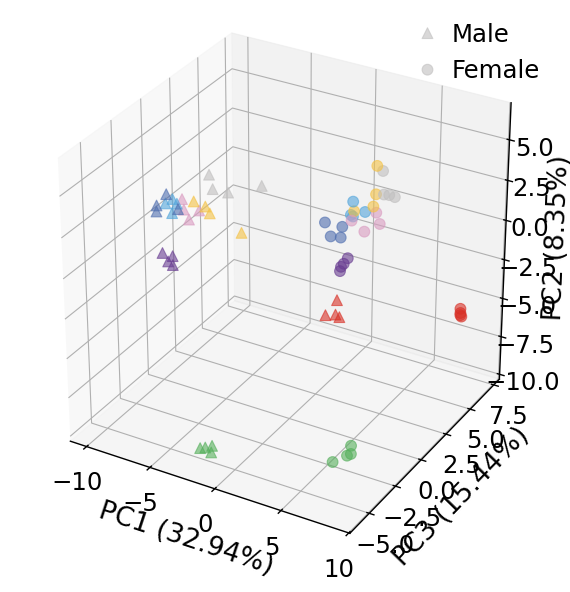

(64, 48217)


/opt/apps/python/3.10.2/lib/python3.10/site-packages/scanpy/preprocessing/_pca/__init__.py:227: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(adata, mask_var, use_highly_variable)


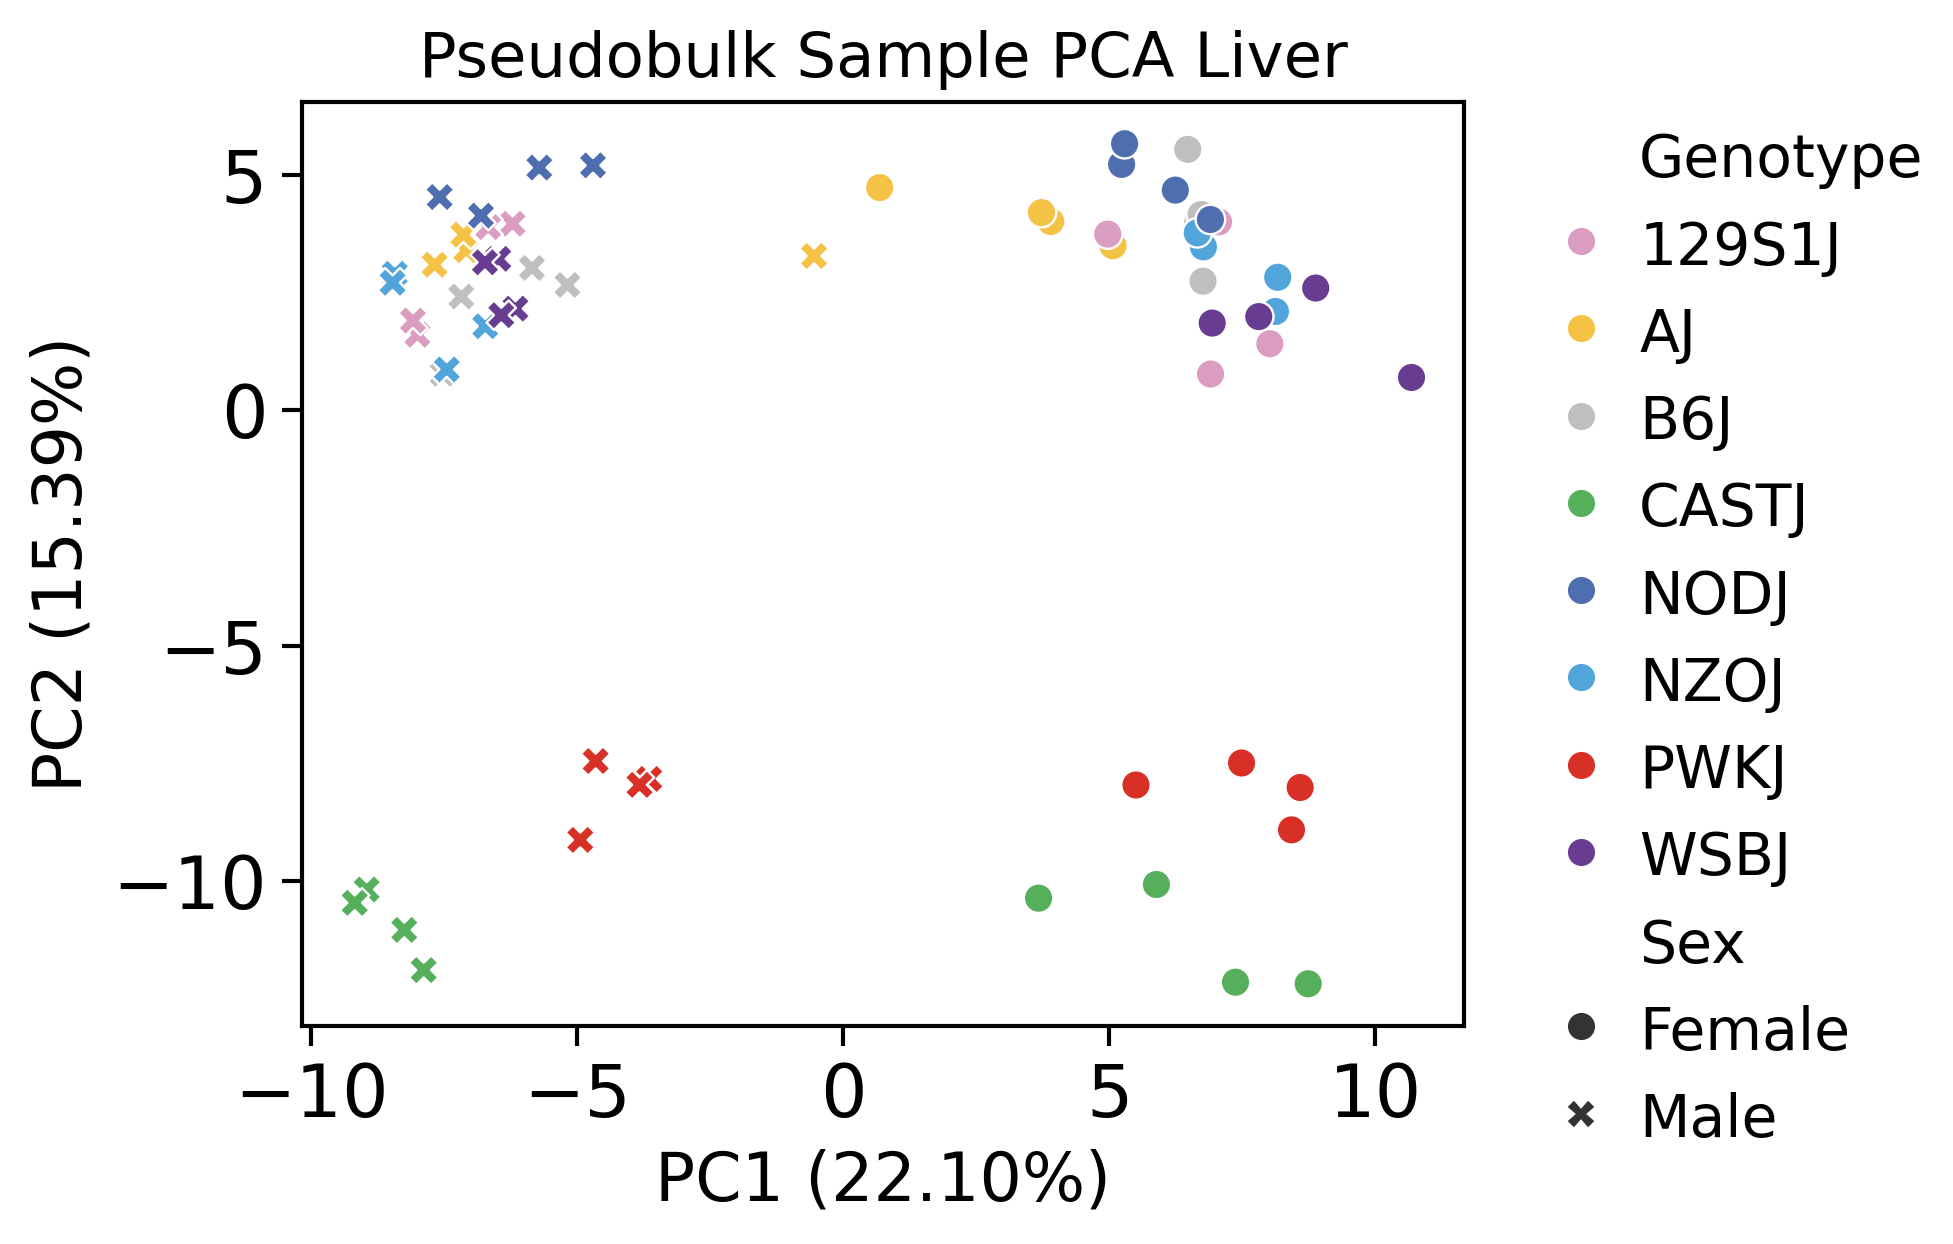

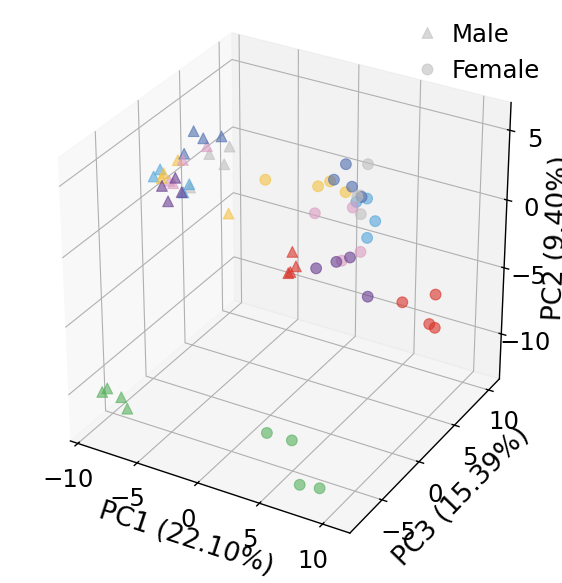

(65, 49304)


/opt/apps/python/3.10.2/lib/python3.10/site-packages/scanpy/preprocessing/_pca/__init__.py:227: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(adata, mask_var, use_highly_variable)


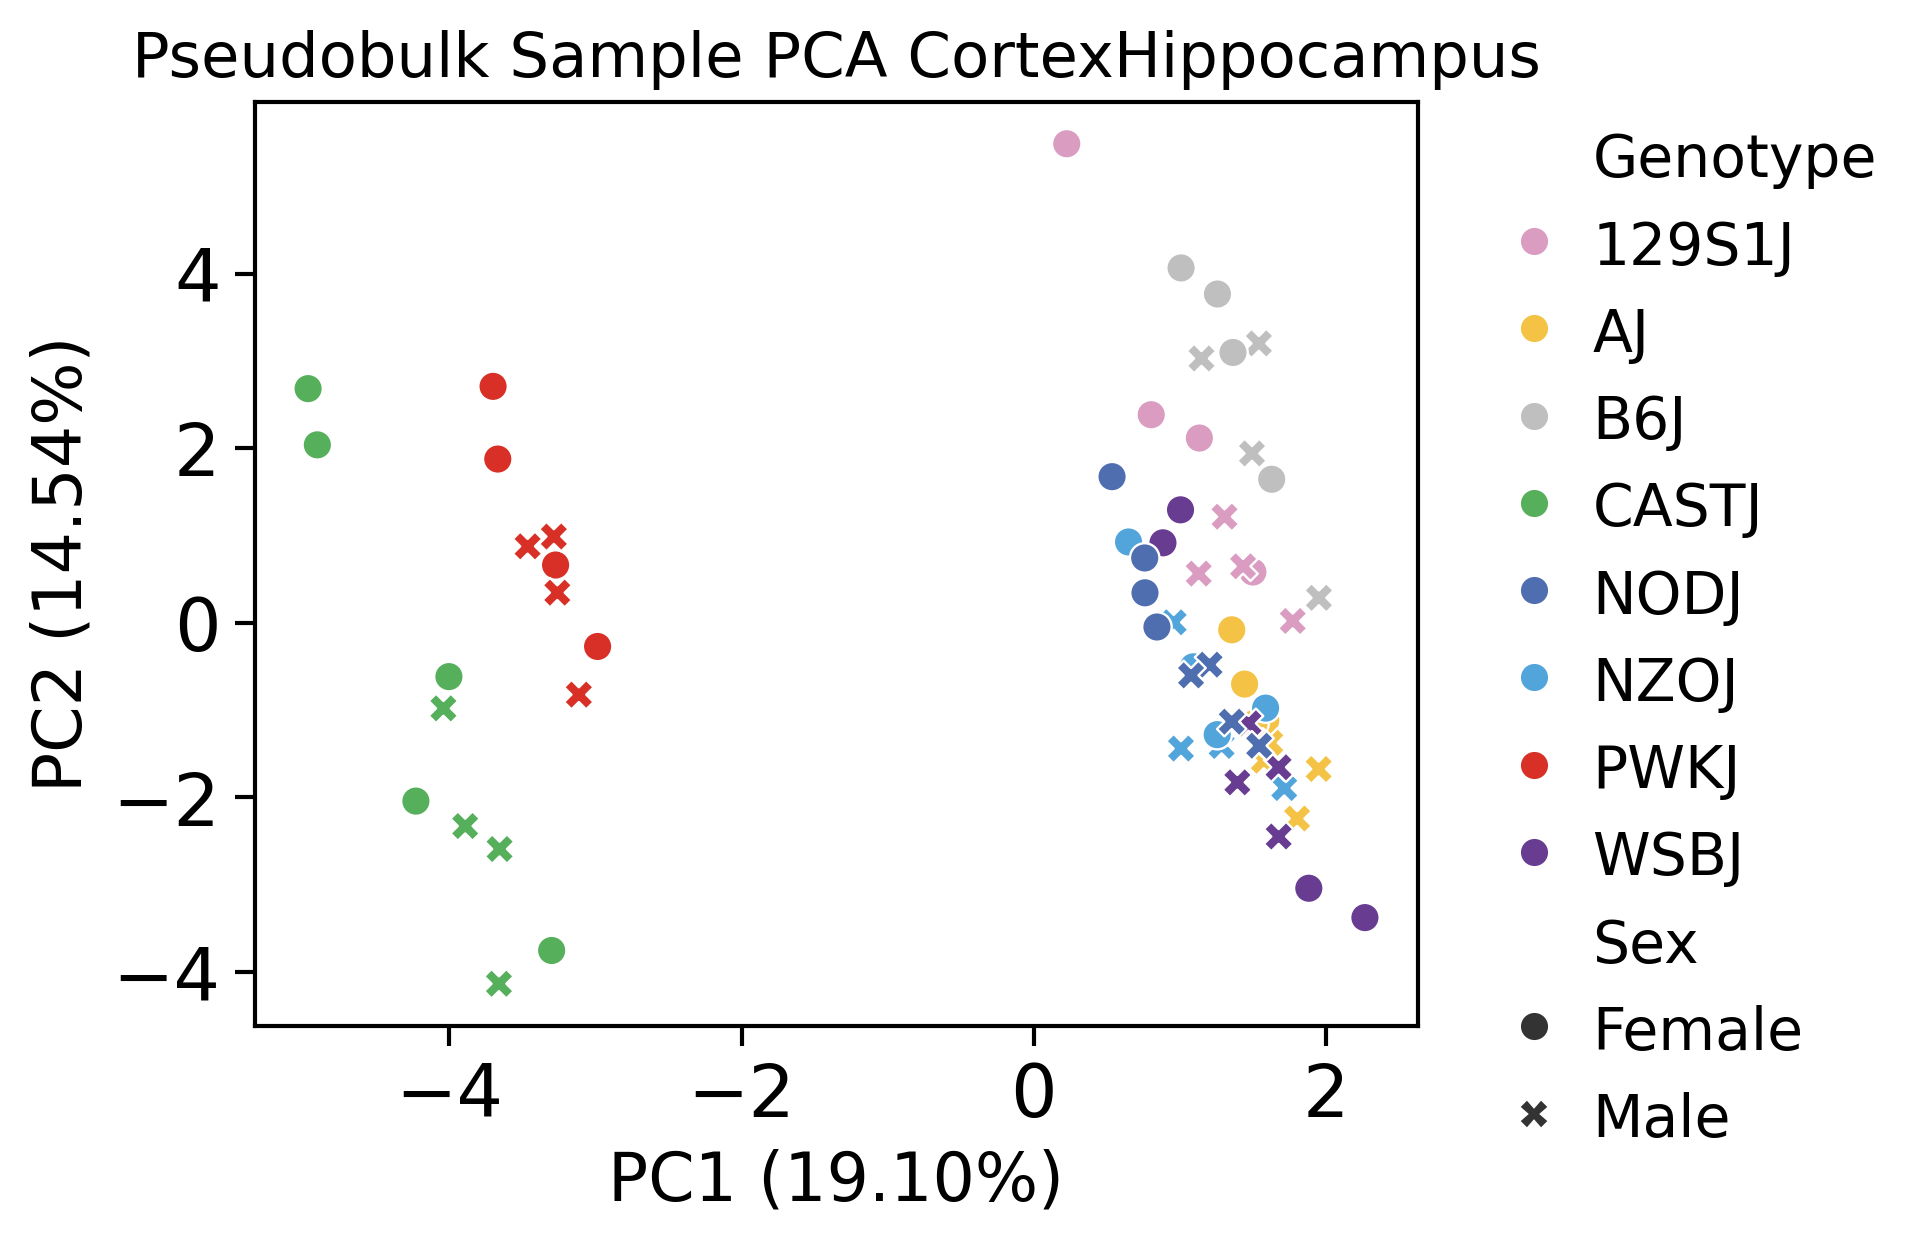

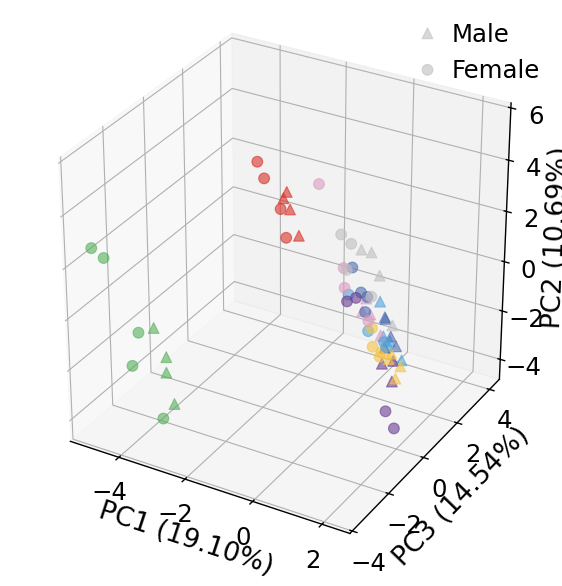

(65, 48900)


/opt/apps/python/3.10.2/lib/python3.10/site-packages/scanpy/preprocessing/_pca/__init__.py:227: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(adata, mask_var, use_highly_variable)


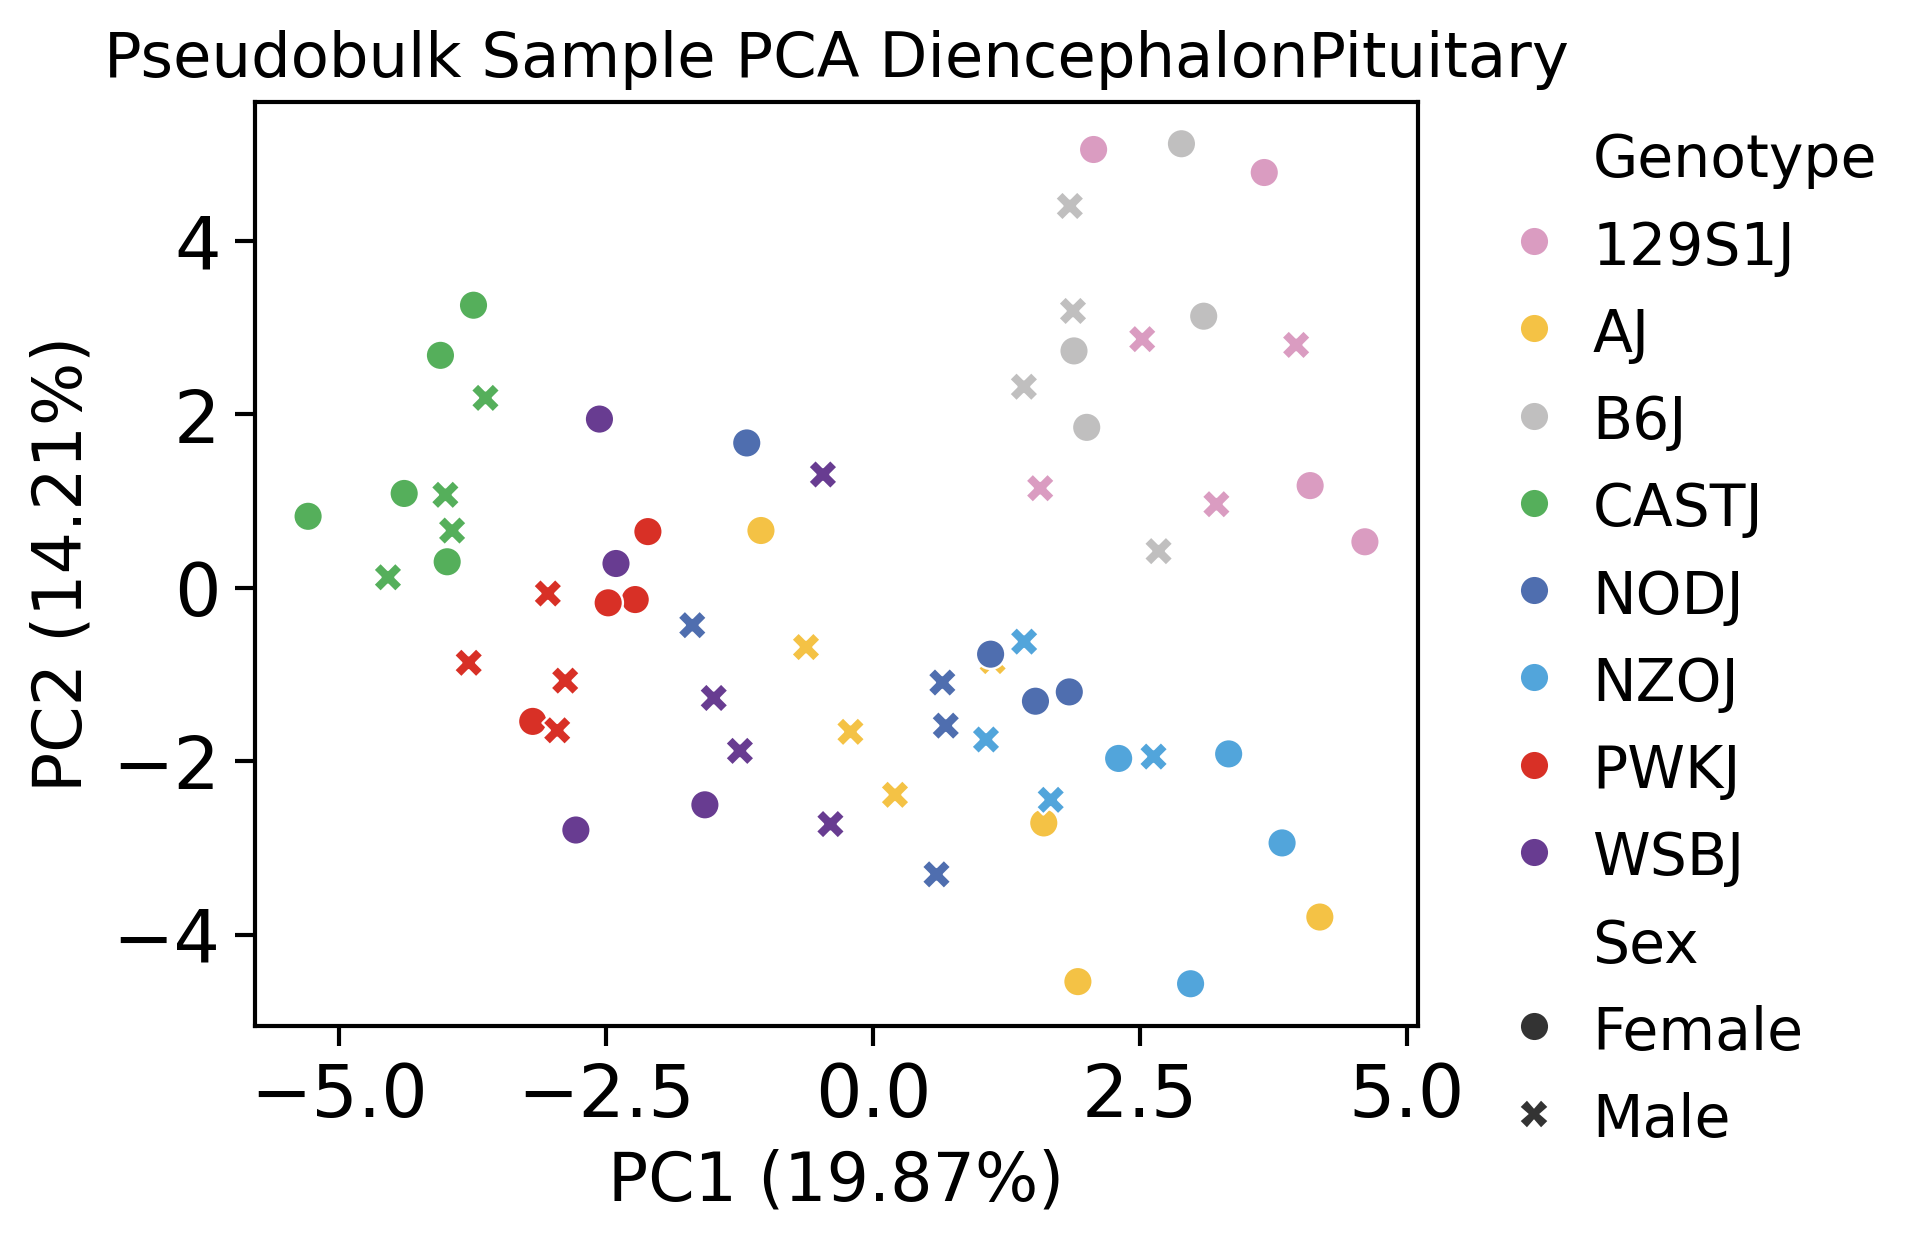

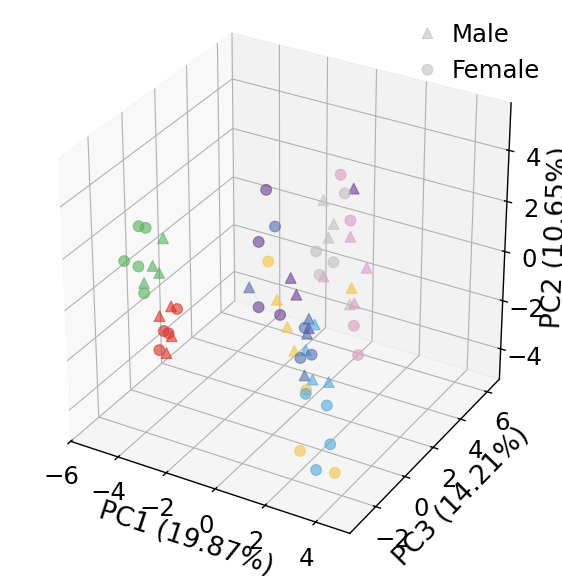

(64, 46753)


/opt/apps/python/3.10.2/lib/python3.10/site-packages/scanpy/preprocessing/_pca/__init__.py:227: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(adata, mask_var, use_highly_variable)


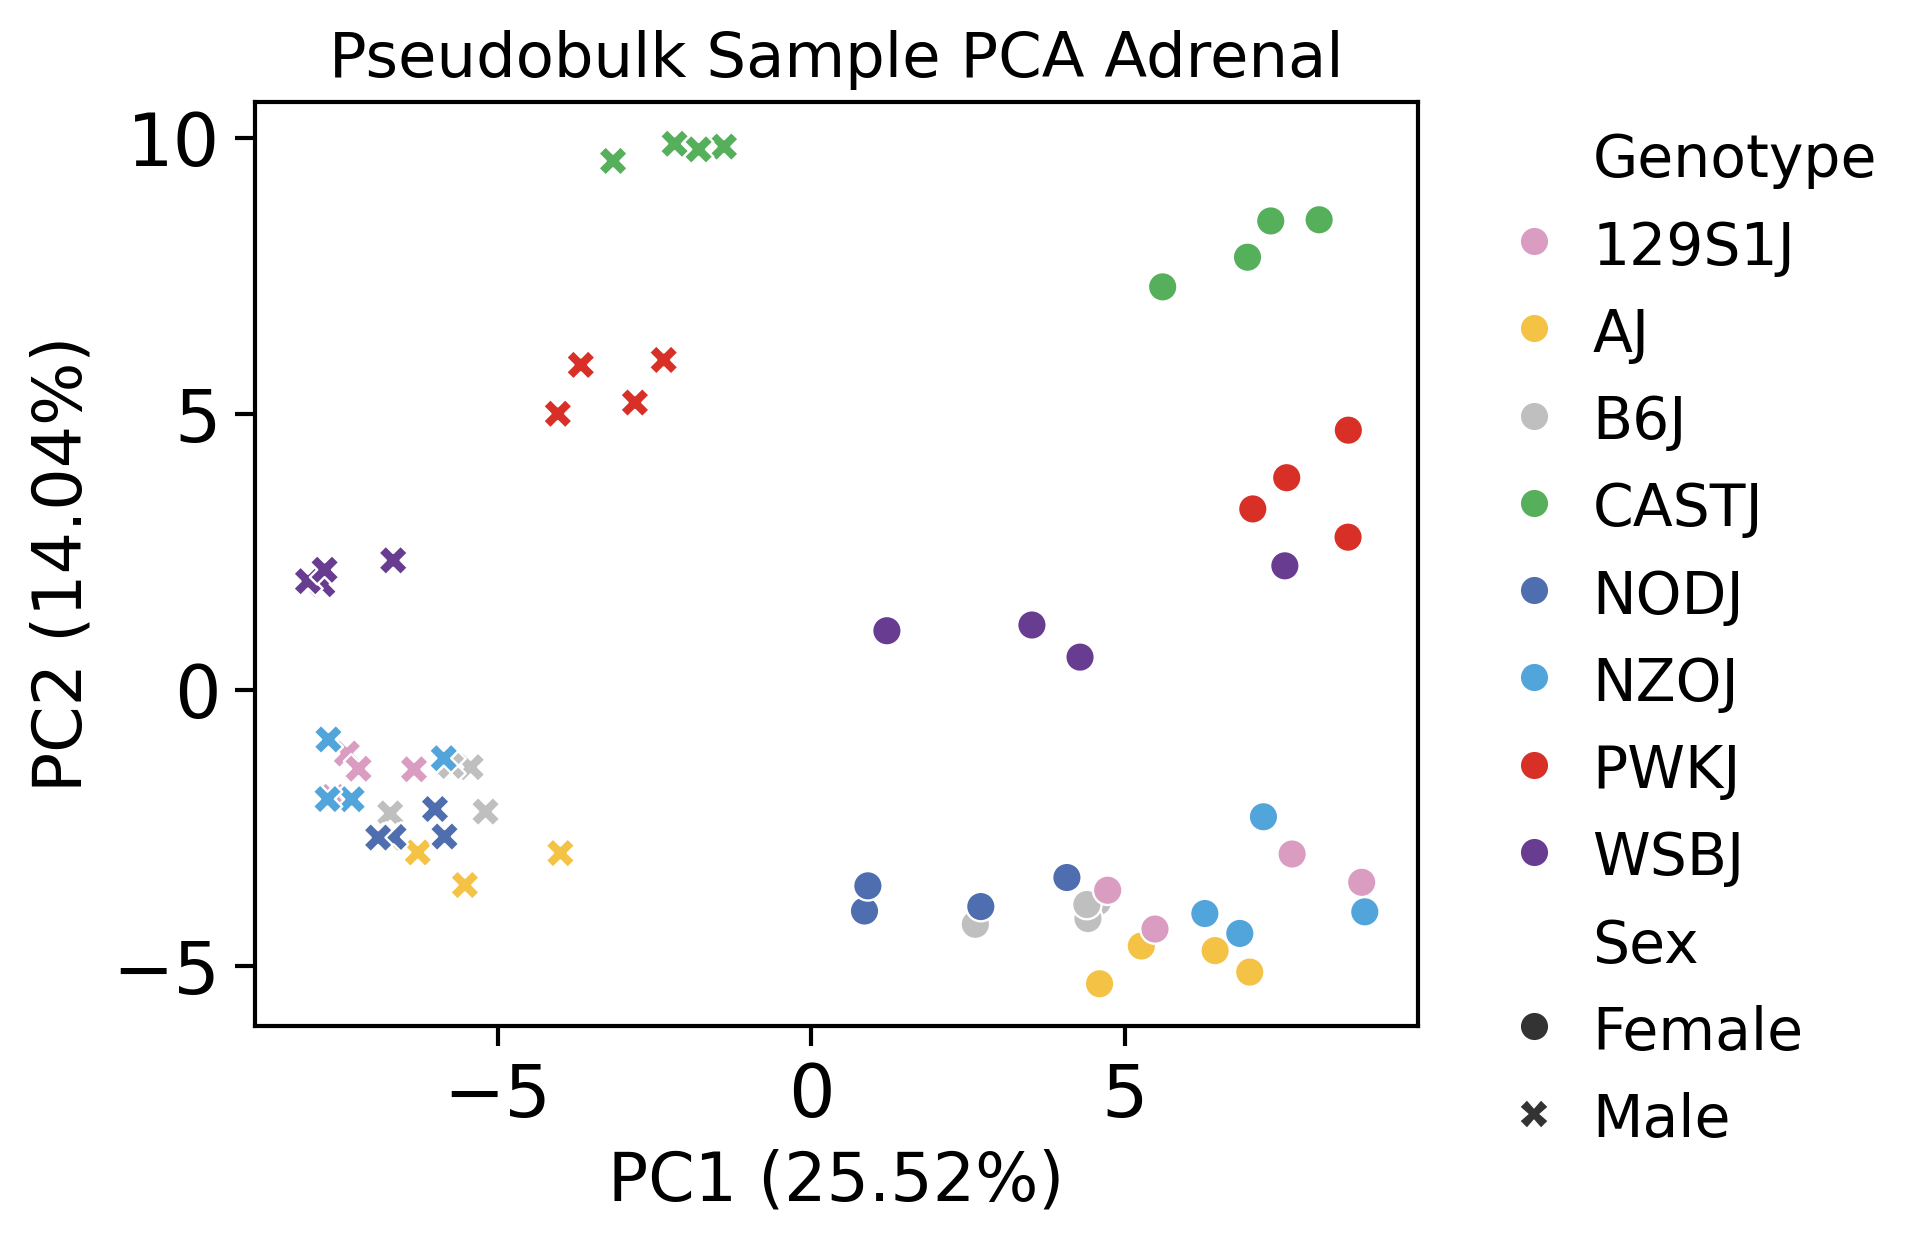

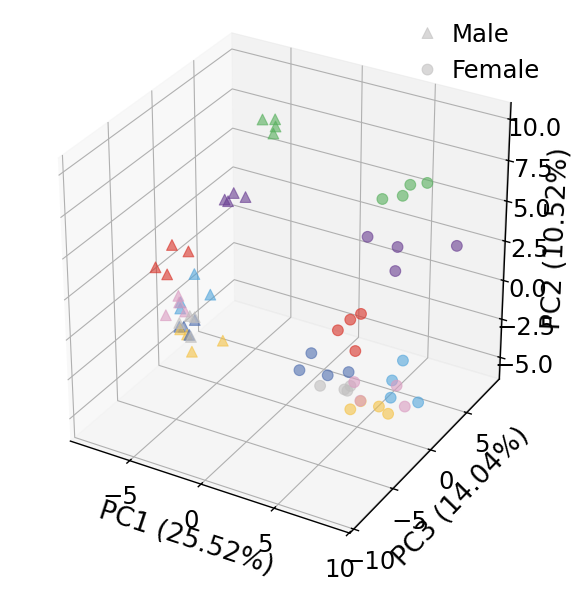

In [8]:
tissues = ["GonadsMale", "GonadsFemale","Gastrocnemius","Heart","Kidney","Liver","CortexHippocampus","DiencephalonPituitary","Adrenal"]
geno_palette = ['#DA9CC1', '#F4C245', '#C0BFBF', '#55AF5B', '#4F6EAF', '#52A5DB', '#D83026', '#683C91']

pdata_list = []

for tissue in tissues:
    pdata = sc.read(f'/share/crsp/lab/seyedam/share/igvf_pipeline/IGVF_analysis/cellbender_tissues/pseudobulk/sample_pseudobulk/{tissue}_sample_pseudobulk.h5ad')
    print(pdata.shape)
    sc.pp.normalize_total(pdata, target_sum=1e4) # Counts per 10k
    sc.pp.log1p(pdata)

    sc.tl.pca(pdata, svd_solver='arpack', use_highly_variable = False)

    pdata.obsm["X_pca"].shape

    df = pd.DataFrame(pdata.obsm["X_pca"])
    meta  = pdata.obs
    df.set_index(meta['Mouse_Tissue_ID'], inplace=True)
    merged_df = pd.merge(df, meta, left_index=True, right_on='Mouse_Tissue_ID')
    plt.figure(figsize=(5, 4), dpi=300)


    sns.scatterplot(x=merged_df.iloc[:, 0], y=merged_df.iloc[:, 1], 
                    hue=merged_df['Genotype'], 
                    style=merged_df['Sex'], 
                    s=50, 
                    palette=geno_palette,
                    alpha=1) 

    plt.xlabel("PC1", fontsize=16)
    plt.ylabel("PC2", fontsize=16)
    plt.title(f'Pseudobulk Sample PCA {tissue}', fontsize=15)

    plt.legend(fontsize=14, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(False)
    pc1 = pdata.uns["pca"]["variance_ratio"][0]
    pc2 = pdata.uns["pca"]["variance_ratio"][1]
    plt.xlabel(f"PC1 ({pc1:.2%})", fontsize=16)
    plt.ylabel(f"PC2 ({pc2:.2%})", fontsize=16)


    plt.show()
    
    
    
    geno_palette_ordered = ['#C0BFBF', '#F4C245','#DA9CC1',  
                            '#52A5DB', 
                            '#683C91', '#4F6EAF', 
                            '#D83026','#55AF5B']
    
    import matplotlib.pyplot as plt
    from mpl_toolkits.mplot3d import Axes3D
    import seaborn as sns

    # Assuming merged_df has columns: [x, y, z, Tissue, Sex]

    fig = plt.figure(figsize=(8, 6))  # Adjust the figure size
    ax = fig.add_subplot(111, projection='3d')

    # Separate data by sex
    male_data = merged_df[merged_df['Sex'] == 'Male']
    female_data = merged_df[merged_df['Sex'] == 'Female']

    # Scatter plot for male data
    ax.scatter(xs=male_data.iloc[:, 0], 
               ys=male_data.iloc[:, 2], 
               zs=male_data.iloc[:, 1],  
               c=male_data['Genotype'].map(dict(zip(merged_df['Genotype'].unique(), geno_palette_ordered))), 
               s=60,  # Marker size
               alpha=0.6,  # Opacity
               marker='^',  # Circle marker for male
               label='Male')

    # Scatter plot for female data
    ax.scatter(xs=female_data.iloc[:, 0], 
               ys=female_data.iloc[:, 2], 
               zs=female_data.iloc[:, 1],  
               c=female_data['Genotype'].map(dict(zip(merged_df['Genotype'].unique(), geno_palette_ordered))), 
               s=60,  # Marker size
               alpha=0.6,  # Opacity
               marker='o',  # Square marker for female
               label='Female')

    pc1 = pdata.uns["pca"]["variance_ratio"][0]
    pc2 = pdata.uns["pca"]["variance_ratio"][2]
    pc3 = pdata.uns["pca"]["variance_ratio"][1]
    ax.set_xlabel(f"PC1 ({pc1:.2%})")
    ax.set_ylabel(f"PC3 ({pc3:.2%})")
    ax.set_zlabel(f"PC2 ({pc2:.2%})")  # Corrected label

    # Adjust the aspect ratio of the plot to make sure all axis labels are visible
    ax.set_box_aspect([0.9,0.9,0.9])  
#     ax.set_xlim([-10, 8])
#     ax.set_ylim([-8, 16])


    plt.tight_layout()  # Adjust the layout to make sure labels are not cut off

    plt.legend()  # Add legend

    #plt.savefig('fig1/pseudobulk_sample_3dpca_color_tissues.pdf', bbox_inches='tight')


    plt.show()


